In [8]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.optim import Adam
from pyro.infer.autoguide import AutoDiagonalNormal, AutoNormal
import matplotlib.pyplot as plt

pyro.set_rng_seed(0)
pyro.clear_param_store()

# -----------------------
# 1) Simulate Gamma data
# -----------------------
true_alpha = 3.0
true_beta  = 2.0   # rate
N = 300
data = dist.Gamma(true_alpha, true_beta).sample((N,))

# -----------------------
# 2) Model
# -----------------------
def model(data):
    alpha = pyro.sample("alpha", dist.LogNormal(2.0, 1.0))  # prior, can be replaced by LogNormal
    beta  = pyro.sample("beta",  dist.LogNormal(2.0, 1.0))  # prior
    with pyro.plate("N", data.size(0)):
        pyro.sample("obs", dist.Gamma(alpha, beta), obs=data)

# -----------------------
# 3) AutoDiagonalNormal guide
# -----------------------
guide = AutoDiagonalNormal(model) # can be replaced by AutoNormal

# -----------------------
# 4) SVI
# -----------------------
svi = SVI(model, guide, Adam({"lr": 0.03}), loss=Trace_ELBO())

losses = []
num_steps = 2500
for step in range(num_steps):
    loss = svi.step(data)
    losses.append(loss)
    if step % 500 == 0:
        print(f"step={step:4d} loss={loss:.2f}")

# -----------------------
# 5) Draw posterior samples from the guide
# -----------------------
S = 5000
predictive = Predictive(model, guide=guide, num_samples=S, return_sites=("alpha", "beta"))
samples = predictive(data)

alpha_s = samples["alpha"].detach().cpu()
beta_s  = samples["beta"].detach().cpu()

alpha_mean, alpha_sd = alpha_s.mean().item(), alpha_s.std().item()
beta_mean, beta_sd   = beta_s.mean().item(),  beta_s.std().item()

print(f"\nVI posterior alpha: mean={alpha_mean:.3f}, sd={alpha_sd:.3f} (true={true_alpha})")
print(f"VI posterior beta : mean={beta_mean:.3f}, sd={beta_sd:.3f} (true={true_beta})")



step=   0 loss=741.28
step= 500 loss=376.06
step=1000 loss=376.69
step=1500 loss=376.57
step=2000 loss=376.04

VI posterior alpha: mean=2.669, sd=0.088 (true=3.0)
VI posterior beta : mean=1.777, sd=0.068 (true=2.0)


In [9]:
# -----------------------
# 6) MLE
# -----------------------

import torch

def gamma_mle_rate_torch(x, max_iter=100, tol=1e-10):
    """
    MLE for Gamma(concentration=alpha, rate=beta) using Newton updates for alpha.
    No SciPy; uses torch.digamma and torch.polygamma.
    """
    x = x.detach().to(torch.double)
    eps = torch.finfo(x.dtype).tiny
    x = torch.clamp(x, min=eps)

    xbar = x.mean()
    s = torch.log(xbar) - torch.log(x).mean()  # s = log(mean) - mean(log x)

    # Method-of-moments init for alpha: alpha0 ≈ mean^2 / var
    v = x.var(unbiased=False)
    alpha = torch.clamp(xbar * xbar / (v + eps), min=1e-3)

    for _ in range(max_iter):
        # f(alpha) = log(alpha) - digamma(alpha) - s
        f = torch.log(alpha) - torch.digamma(alpha) - s
        # f'(alpha) = 1/alpha - trigamma(alpha)
        fp = 1.0 / alpha - torch.polygamma(1, alpha)

        step = f / fp
        alpha_new = alpha - step
        alpha_new = torch.clamp(alpha_new, min=1e-8)

        if torch.max(torch.abs(alpha_new - alpha)) < tol:
            alpha = alpha_new
            break
        alpha = alpha_new

    beta = alpha / xbar
    return alpha.item(), beta.item()

alpha_mle, beta_mle = gamma_mle_rate_torch(data.cpu())
print(f"MLE alpha={alpha_mle:.4f}, beta={beta_mle:.4f}")


MLE alpha=2.7040, beta=1.7379


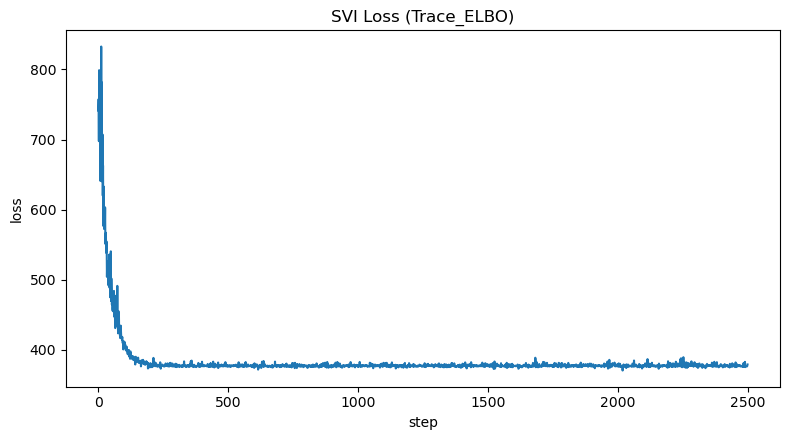

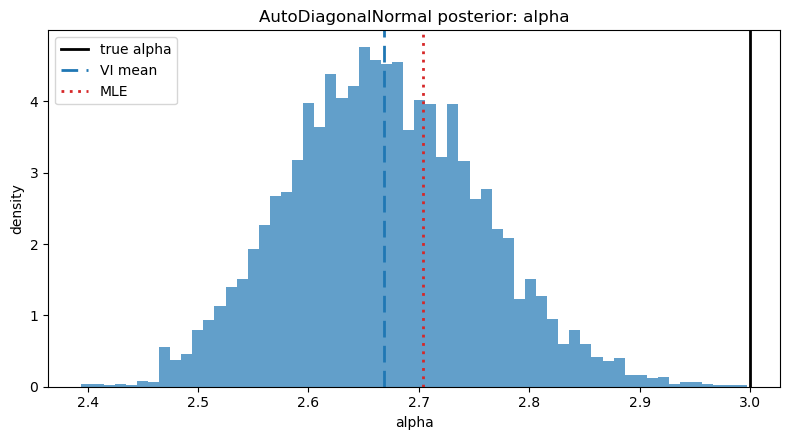

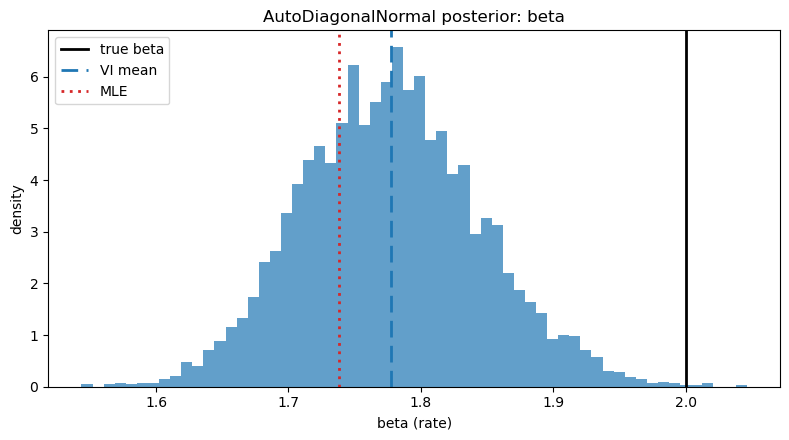

In [10]:
# -----------------------
# 7) Visualize
# -----------------------
plt.figure(figsize=(8, 4.5))
plt.plot(losses)
plt.title("SVI Loss (Trace_ELBO)")
plt.xlabel("step")
plt.ylabel("loss")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.hist(alpha_s.numpy(), bins=60, density=True, alpha=0.7)
plt.axvline(true_alpha, color="k",  linestyle="-",             linewidth=2, label="true alpha")
plt.axvline(alpha_mean, color="C0", linestyle=(0, (6, 3)),     linewidth=2, label="VI mean")
plt.axvline(alpha_mle,  color="C3", linestyle=(0, (1, 2)),     linewidth=2, label="MLE")
plt.title("AutoDiagonalNormal posterior: alpha")
plt.xlabel("alpha")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.hist(beta_s.numpy(), bins=60, density=True, alpha=0.7)
plt.axvline(true_beta, color="k",  linestyle="-",             linewidth=2, label="true beta")
plt.axvline(beta_mean, color="C0", linestyle=(0, (6, 3)),     linewidth=2, label="VI mean")
plt.axvline(beta_mle,  color="C3", linestyle=(0, (1, 2)),     linewidth=2, label="MLE")
plt.title("AutoDiagonalNormal posterior: beta")
plt.xlabel("beta (rate)")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()